In [1]:
# title import pkg
import warnings

warnings.filterwarnings("ignore")

import sys
import os


import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

import re
from tqdm import tqdm
from IPython.display import clear_output

from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.linear_model import (
    LogisticRegressionCV,
    LassoCV,
    Lasso,
    LogisticRegression,
)


sys.path.append(os.path.abspath("../"))
from dmldid.model_rcs import DMLDiD_RCS

from dmldid.simdata_genrater import generate_simdata_ro, convert_rcs

# Verification with simulation data
## simulation data
-  repeated cross-section data
- true ATT := 3
- dim(X) := 100
- N = 600

In [2]:
df_rcs = convert_rcs(
    generate_simdata_ro(true_att=3, _n=500, _dim=10, base_seed=1, xd_unobserved=False)
)

df_rcs.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,D,Y,T
0,1.624345,-0.611756,-0.528172,-1.072969,0.865408,-2.301539,1.744812,-0.761207,0.319039,-0.249370,0,-3.112367,0
1,1.462108,-2.060141,-0.322417,-0.384054,1.133769,-1.099891,-0.172428,-0.877858,0.042214,0.582815,0,-5.914959,1
2,-1.100619,1.144724,0.901591,0.502494,0.900856,-0.683728,-0.122890,-0.935769,-0.267888,0.530355,0,-6.522200,0
3,-0.691661,-0.396754,-0.687173,-0.845206,-0.671246,-0.012665,-1.117310,0.234416,1.659802,0.742044,0,-11.119908,0
4,-0.191836,-0.887629,-0.747158,1.692455,0.050808,-0.636996,0.190915,2.100255,0.120159,0.617203,0,-5.385301,0


## naive DiD

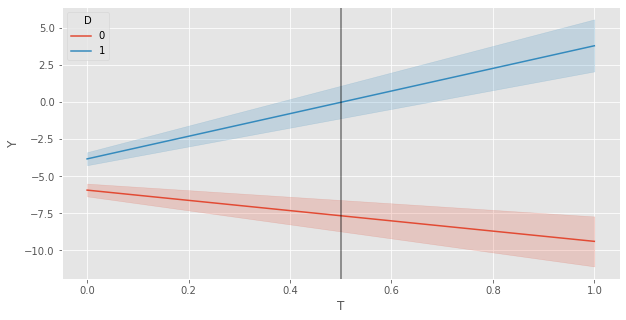

In [3]:
fig, ax = plt.subplots(1, 1, sharex="col", sharey="row", figsize=(10, 5))
sns.lineplot(x="T", y="Y", hue="D", data=df_rcs, ax=ax)
ax.axvline(x=0.5, alpha=0.5, color="black")
plt.show()

In [4]:
y_col = "Y"
d_col = "D"
t_col = "T"
X_cols = [col for col in df_rcs.columns if "x" in col]

# x->d unobserved

In [5]:
dml_with_separate = []
lgbm_dml = []
abadie_semidid = []


y_col = "Y"
d_col = "D"
t_col = "T"

sim_cnt = 100
for i in range(sim_cnt):
    df = convert_rcs(
        generate_simdata_ro(_dim=100, _n=10000, base_seed=i, xd_unobserved=True)
    )
    X_cols = [col for col in df.columns if "x" in col]

    _dmldid = DMLDiD_RCS(
        d_model=LGBMClassifier(random_state=123),
        l2k_model=LGBMRegressor(random_state=123),
    )
    _dmldid.fit(
        df,
        y_col,
        d_col,
        t_col,
        X_cols,
        dmldid=True,
        sim_cnt=1,
        base_random_seed=0,
        d_model_t0_only=False,
        l2k_model_separate=True,
    )
    dml_with_separate.append(_dmldid.att())
    
    _dmldid = DMLDiD_RCS(
        d_model=LGBMClassifier(random_state=123),
        l2k_model=LGBMRegressor(random_state=123),
    )
    _dmldid.fit(
        df,
        y_col,
        d_col,
        t_col,
        X_cols,
        dmldid=True,
        sim_cnt=1,
        base_random_seed=0,
        d_model_t0_only=False,
        l2k_model_separate=False,
    )
    lgbm_dml.append(_dmldid.att())

    _dmldid = DMLDiD_RCS(
        d_model=LGBMClassifier(random_state=123),
        l2k_model=LGBMRegressor(random_state=123),
    )
    _dmldid.fit(
        df,
        y_col,
        d_col,
        t_col,
        X_cols,
        dmldid=False,
        sim_cnt=1,
        base_random_seed=0,
        d_model_t0_only=False,
    )
    abadie_semidid.append(_dmldid.att())

    clear_output(wait=True)
    print(f"{i} modified DMLDiD : ", np.mean(dml_with_separate))
    print(f"{i} modified DMLDiD no separate : ", np.mean(lgbm_dml))
    print(f"{i} abadie_semidid : ", np.mean(abadie_semidid))



99 modified DMLDiD :  2.867498790290514
99 modified DMLDiD no separate :  2.8253036304678276
99 abadie_semidid :  5.80287876804111


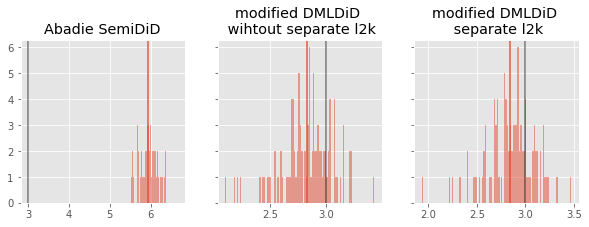

In [16]:
_label = [
    "Abadie SemiDiD",
    "modified DMLDiD \n wihtout separate l2k",
    "modified DMLDiD \n separate l2k",
]
result_df = pd.DataFrame(
    {
        "abadie_semidid": abadie_semidid,
        "modified_dmldid": lgbm_dml,
        "modified_dmldid_with_separate": dml_with_separate
    }
)
fig, ax = plt.subplots(1, 3, sharex="col", sharey="row", figsize=(10, 3))
ax = ax.ravel()
for i, _col in enumerate(result_df.columns):
    ax[i].hist(result_df[_col], bins=100, alpha=0.5)
    #ax[i].set_xlim(0,10)
    ax[i].set_title(_label[i])
    ax[i].axvline(x=3, alpha=0.5, color="black")
    ax[i].axvline(x=result_df[_col].mean(), alpha=0.9)

fig.savefig("../fig/simdata_result_unobserved_ps_lgbm.png")
plt.show()

In [7]:
result_df.describe().T

,count,mean,std,min,25%,50%,75%,max
abadie_semidid,100.0,5.802879,0.286087,5.168731,5.615859,5.802638,6.015796,6.420604
modified_dmldid,100.0,2.825304,0.241358,1.745696,2.710881,2.822258,2.999091,3.262705
modified_dmldid_with_separate,100.0,2.867499,0.250847,1.673756,2.761616,2.888832,3.015670,3.432187


In [11]:
print("Done")

Done
